In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import scipy.sparse as sp
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc
)

sns.set_theme(style='whitegrid', palette='muted')

y_train = pd.read_csv('y_train.csv').values.ravel()
y_test  = pd.read_csv('y_test.csv').values.ravel()

matrices = {
    'BoW':          (sp.load_npz('X_train_bow.npz'),   sp.load_npz('X_test_bow.npz')),
    'TF-IDF':       (sp.load_npz('X_train_tfidf.npz'), sp.load_npz('X_test_tfidf.npz')),
}


import glob
for path in sorted(glob.glob('X_train_ngram_*.npz')):
    name = path.replace('X_train_ngram_', '').replace('.npz', '').replace('_', ' ')
    test_path = path.replace('X_train', 'X_test')
    matrices[name] = (sp.load_npz(path), sp.load_npz(test_path))

print('Représentations disponibles :', list(matrices.keys()))

Représentations disponibles : ['BoW', 'TF-IDF', 'Bigrammes 22', 'Uni+Bi+Tri 13', 'Uni+Bi 12', 'Unigrammes 11']


In [2]:
models = {
    'Naive Bayes':  MultinomialNB(alpha=0.1),
    'SVM':          LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'Log. Reg.':    LogisticRegression(C=1.0, max_iter=500, random_state=42),
}

results = []

for vec_name, (X_tr, X_te) in matrices.items():
    for model_name, model in models.items():
        # Clone du modèle pour chaque combinaison
        m = model.__class__(**model.get_params())
        m.fit(X_tr, y_train)
        y_pred = m.predict(X_te)

        if hasattr(m, 'predict_proba'):
            y_score = m.predict_proba(X_te)[:, 1]
        elif hasattr(m, 'decision_function'):
            y_score = m.decision_function(X_te)
        else:
            y_score = y_pred

        results.append({
            'vectorizer':  vec_name,
            'model':       model_name,
            'accuracy':    accuracy_score(y_test, y_pred),
            'precision':   precision_score(y_test, y_pred),
            'recall':      recall_score(y_test, y_pred),
            'f1':          f1_score(y_test, y_pred),
            'roc_auc':     roc_auc_score(y_test, y_score),
            '_model_obj':  m,
            '_X_test':     X_te,
            '_y_score':    y_score,
        })
        print(f'{vec_name:<30} {model_name:<15} → F1={f1_score(y_test,y_pred):.4f}')

df_results = pd.DataFrame(results)

BoW                            Naive Bayes     → F1=0.9215
BoW                            SVM             → F1=0.9379
BoW                            Log. Reg.       → F1=0.9286
TF-IDF                         Naive Bayes     → F1=0.9104
TF-IDF                         SVM             → F1=0.9404
TF-IDF                         Log. Reg.       → F1=0.8626
Bigrammes 22                   Naive Bayes     → F1=0.8897
Bigrammes 22                   SVM             → F1=0.8636
Bigrammes 22                   Log. Reg.       → F1=0.5100
Uni+Bi+Tri 13                  Naive Bayes     → F1=0.9058
Uni+Bi+Tri 13                  SVM             → F1=0.9306
Uni+Bi+Tri 13                  Log. Reg.       → F1=0.8712
Uni+Bi 12                      Naive Bayes     → F1=0.9214
Uni+Bi 12                      SVM             → F1=0.9306
Uni+Bi 12                      Log. Reg.       → F1=0.8755
Unigrammes 11                  Naive Bayes     → F1=0.9104
Unigrammes 11                  SVM             → F1=0.94

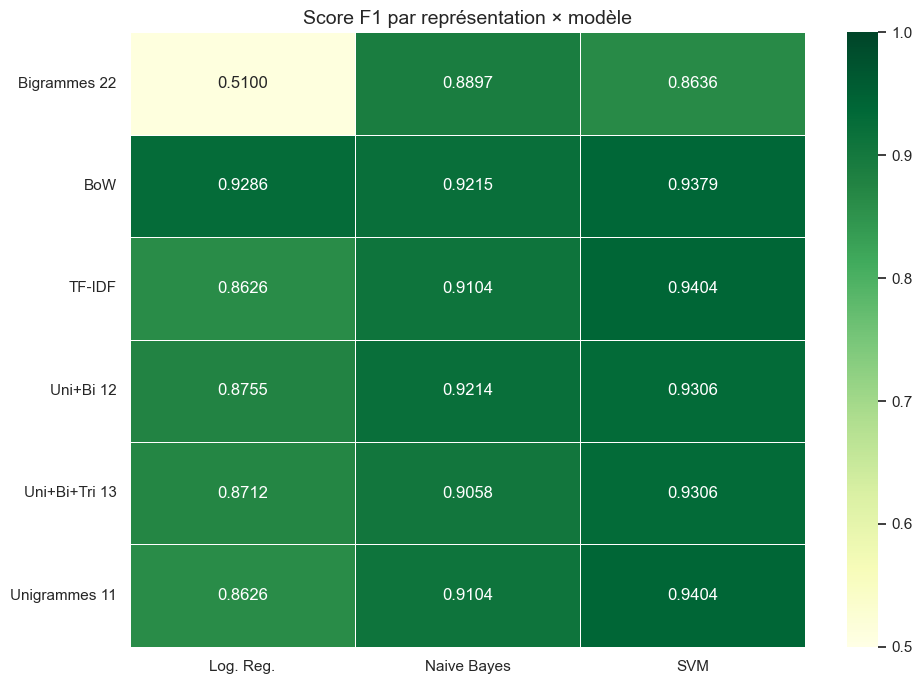

In [3]:
pivot_f1 = df_results.pivot_table(index='vectorizer', columns='model', values='f1')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='YlGn',
            vmin=pivot_f1.values.min() - 0.01,
            vmax=1.0, linewidths=0.5, ax=ax, annot_kws={'size': 12})
ax.set_title('Score F1 par représentation × modèle', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

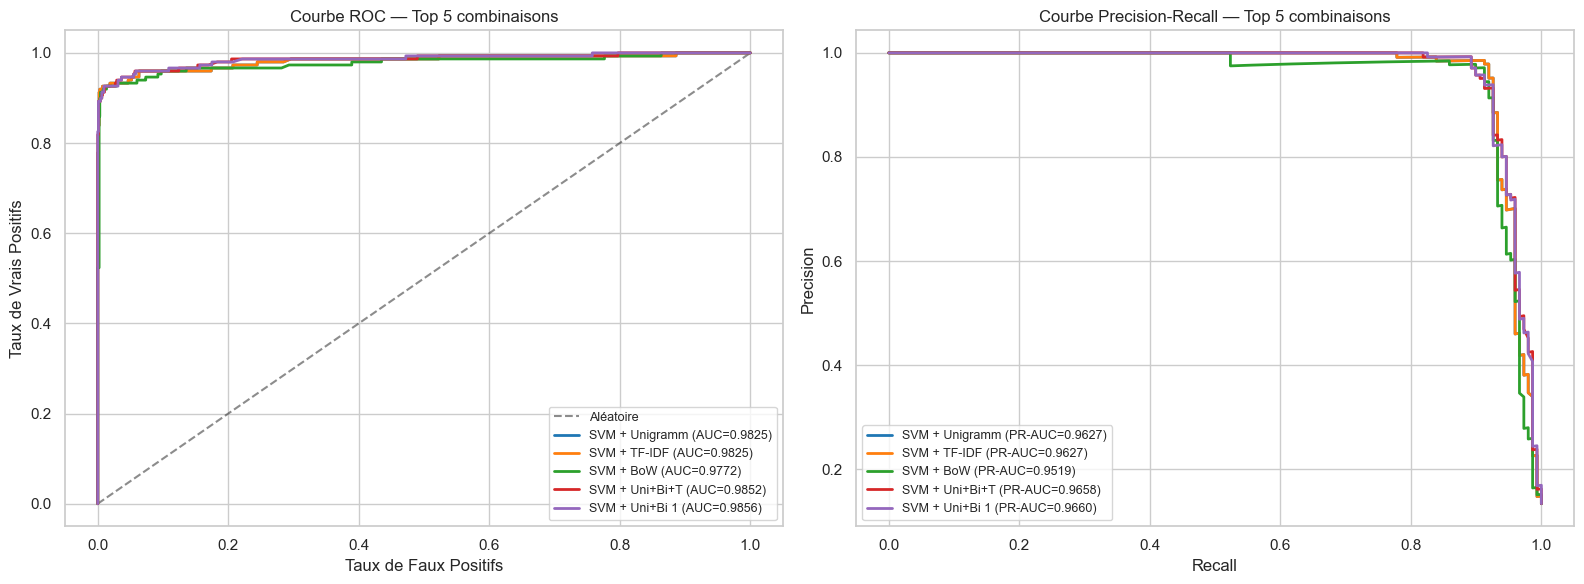

In [4]:
# Sélectionner les 5 meilleures combinaisons par F1
top5 = df_results.sort_values('f1', ascending=False).head(5)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


ax = axes[0]
ax.plot([0,1], [0,1], 'k--', alpha=0.5, label='Aléatoire')
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
for (_, row), color in zip(top5.iterrows(), colors):
    fpr, tpr, _ = roc_curve(y_test, row['_y_score'])
    label = f"{row['model']} + {row['vectorizer'][:8]} (AUC={row['roc_auc']:.4f})"
    ax.plot(fpr, tpr, color=color, lw=2, label=label)
ax.set_xlabel('Taux de Faux Positifs')
ax.set_ylabel('Taux de Vrais Positifs')
ax.set_title('Courbe ROC — Top 5 combinaisons')
ax.legend(fontsize=9)


ax = axes[1]
for (_, row), color in zip(top5.iterrows(), colors):
    prec, rec, _ = precision_recall_curve(y_test, row['_y_score'])
    pr_auc = auc(rec, prec)
    label = f"{row['model']} + {row['vectorizer'][:8]} (PR-AUC={pr_auc:.4f})"
    ax.plot(rec, prec, color=color, lw=2, label=label)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Courbe Precision-Recall — Top 5 combinaisons')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

Analyse des erreurs — Faux Positifs (ham classé spam)

In [5]:
# Prendre le meilleur modèle global
best_row = df_results.sort_values('f1', ascending=False).iloc[0]
best_model = best_row['_model_obj']
best_X_test = best_row['_X_test']

print(f'Meilleur modèle : {best_row["model"]} + {best_row["vectorizer"]}')
print(f'F1 = {best_row["f1"]:.4f}')

y_pred_best = best_model.predict(best_X_test)

df_orig = pd.read_csv('data_raw.csv')

from sklearn.model_selection import train_test_split
df_orig['label_enc'] = (df_orig['label'] == 'spam').astype(int)
_, X_raw_test, _, _ = train_test_split(df_orig['text'], df_orig['label_enc'],
                                        test_size=0.2, random_state=42,
                                        stratify=df_orig['label_enc'])

test_texts = X_raw_test.reset_index(drop=True)
y_test_series = pd.Series(y_test, name='true')
y_pred_series = pd.Series(y_pred_best, name='pred')

errors_df = pd.DataFrame({
    'text': test_texts,
    'true': y_test_series,
    'pred': y_pred_series
})

# Faux positifs : ham prédit comme spam
fp = errors_df[(errors_df['true']==0) & (errors_df['pred']==1)]
print(f'\n=== Faux Positifs : {len(fp)} emails ham classés comme spam ===')
for _, row in fp.head(5).iterrows():
    print(f'  → {row["text"][:120]}')

# Faux négatifs : spam non détecté
fn = errors_df[(errors_df['true']==1) & (errors_df['pred']==0)]
print(f'\n=== Faux Négatifs : {len(fn)} spams non détectés ===')
for _, row in fn.head(5).iterrows():
    print(f'  → {row["text"][:120]}')

Meilleur modèle : SVM + Unigrammes 11
F1 = 0.9404

=== Faux Positifs : 2 emails ham classés comme spam ===
  → Did u receive my msg?
  → K..u also dont msg or reply to his msg..

=== Faux Négatifs : 15 spams non détectés ===
  → FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std
  → ringtoneking 84484
  → Sorry I missed your call let's talk when you have the time. I'm on 07090201529
  → Latest News! Police station toilet stolen, cops have nothing to go on!
  → Romantic Paris. 2 nights, 2 flights from £79 Book now 4 next year. Call 08704439680Ts&Cs apply.


## Conclusions 


**Représentation vectorielle**
- **BoW** : simple et efficace comme baseline. Les fréquences brutes suffisent pour des cas évidents.
- **TF-IDF** : généralement meilleur que BoW car il réduit l'importance des mots trop communs.
- **N-grams** : capturent des patterns comme `"click here"` ou `"free prize"`. 
**Modèles**
- **Naive Bayes** : excellent ratio performance/vitesse.
- **SVM** : souvent le meilleur en haute dimension. Robuste, peu de réglages nécessaires.
- **Logistic Regression** : similaire à SVM, plus interprétable .
- **Random Forest** : décevant sur du texte TF-IDF (arbres de décision + haute dimensionnalité = pas optimal).

**Pre-processing**
- La lemmatisation > stemming pour la qualité, mais le stemming est souvent suffisant.
- La suppression des stop words est très importante pour le BoW, moins cruciale avec TF-IDF .